First 5 Rows:

   Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
0  13500         23  46986    Diesel  90          0  2000      3          4   
1  13750         23  72937    Diesel  90          0  2000      3          4   
2  13950         24  41711    Diesel  90          0  2000      3          4   
3  14950         26  48000    Diesel  90          0  2000      3          4   
4  13750         30  38500    Diesel  90          0  2000      3          4   

   Gears  Weight  
0      5    1165  
1      5    1165  
2      5    1165  
3      5    1165  
4      5    1170  

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 


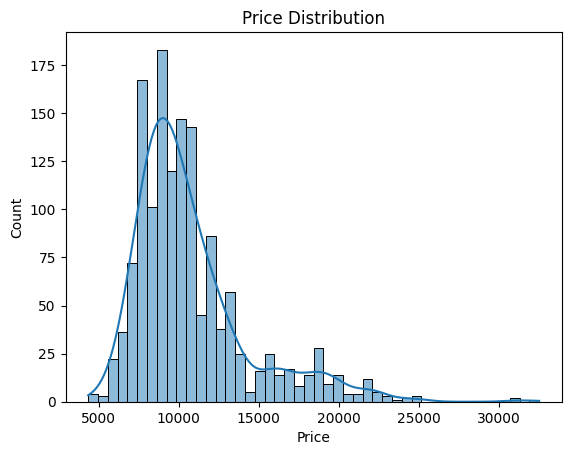

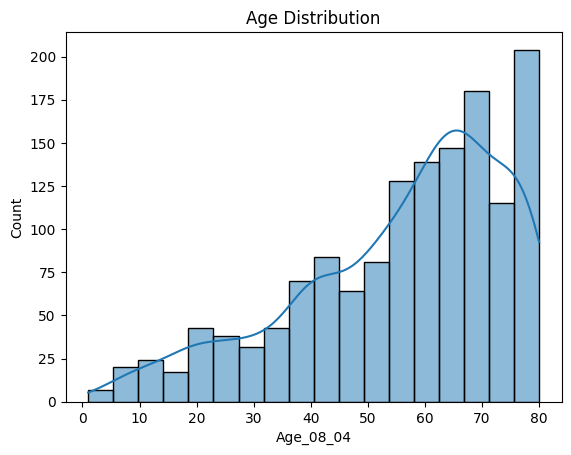

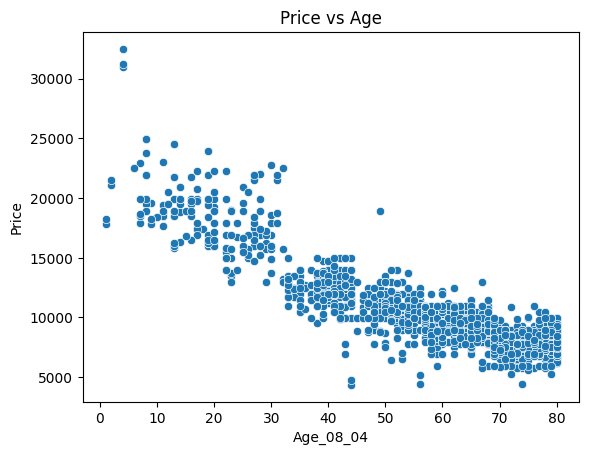

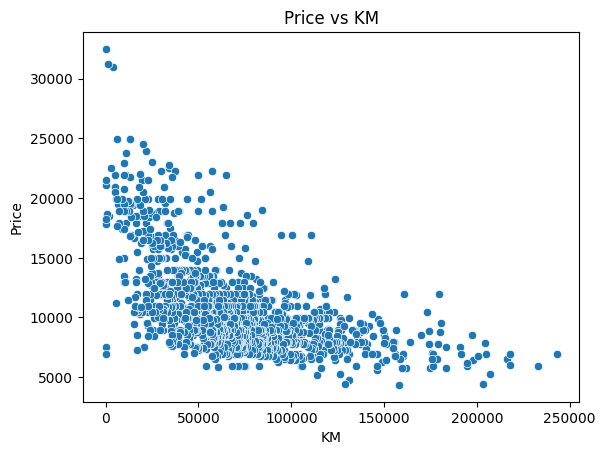


Linear Regression Performance
R2 Score: 0.8523452141908852
RMSE: 1403.6119936838077

Linear Regression Coefficients
     Feature  Coefficient
0  Age_08_04 -2266.406827
1         KM  -753.150324
2         HP   407.055792
3  Automatic    85.792074
4         cc   -52.928989
5      Doors     7.180232
6      Gears   124.171076
7     Weight  1009.459142

Ridge Regression Performance
R2 Score: 0.8523282499142726
RMSE: 1403.6926228963946

Lasso Regression Performance
R2 Score: 0.8523482967385115
RMSE: 1403.5973422000177

VIF Values:

     Feature          VIF
0      const  1378.328904
1  Age_08_04     1.909676
2         KM     1.679142
3         HP     1.218066
4  Automatic     1.047677
5         cc     1.150898
6      Doors     1.155484
7      Gears     1.109188
8     Weight     1.664910


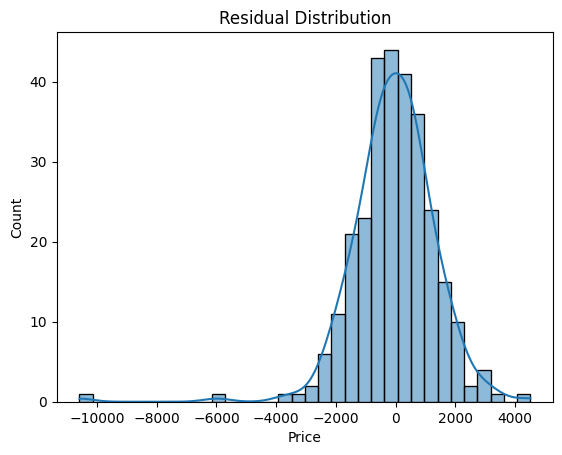


Project Completed Successfully ✅


'\n1. What is Normalization?\na.Normalization scales data between 0 and 1.\nb.Used when features have different ranges.\n\n2. What is Standardization?\na.Standardization transforms data so that:\nb.Mean = 0;Standard Deviation = 1\nc.Used in Linear Regression, Logistic Regression, SVM, Neural Networks.\n\n3. What is Multicollinearity?\na]Multicollinearity occurs when independent variables are highly correlated.\nb]Problems it causes:\n.Unstable coefficients\n.Reduced model interpretability\n.Inflated variance\n\n4. Techniques to Handle Multicollinearity\na]Remove highly correlated variables\nb]Use VIF (Variance Inflation Factor)\nc]Apply Ridge Regression\nd]Apply Lasso Regression\ne]Use PCA\n'

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Load Dataset
dataset = pd.read_csv('/kaggle/input/datasets/vedantthokal/assignment7/ToyotaCorolla - MLR.csv')

print("First 5 Rows:\n")
print(dataset.head())

print("\nDataset Info:\n")
dataset.info()

print("\nStatistical Summary:\n")
print(dataset.describe())

print("\nMissing Values:\n")
print(dataset.isnull().sum())

# -------------------------
# Exploratory Data Analysis
# -------------------------

plt.figure()
sns.histplot(dataset['Price'], kde=True)
plt.title("Price Distribution")
plt.show()

plt.figure()
sns.histplot(dataset['Age_08_04'], kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure()
sns.scatterplot(x='Age_08_04', y='Price', data=dataset)
plt.title("Price vs Age")
plt.show()

plt.figure()
sns.scatterplot(x='KM', y='Price', data=dataset)
plt.title("Price vs KM")
plt.show()

# -------------------------
# Selecting Numerical Features
# -------------------------

dataset_numeric = dataset.select_dtypes(include=[np.number])

X = dataset_numeric.drop(["Price","Cylinders"], axis=1)
y = dataset_numeric["Price"]

# -------------------------
# Train Test Split
# -------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# Feature Scaling (Standardization)
# -------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------
# Model 1 : Linear Regression
# -------------------------

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("\nLinear Regression Performance")
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

# Coefficients Interpretation

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

print("\nLinear Regression Coefficients")
print(coefficients)

# -------------------------
# Model 2 : Ridge Regression
# -------------------------

ridge_model = Ridge(alpha=1)

ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

print("\nRidge Regression Performance")
print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

# -------------------------
# Model 3 : Lasso Regression
# -------------------------

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)

print("\nLasso Regression Performance")
print("R2 Score:", r2_score(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

# -------------------------
# Multicollinearity Check using VIF
# -------------------------

X_with_const = add_constant(X)

vif_data = pd.DataFrame()

vif_data["Feature"] = X_with_const.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_with_const.values, i)
    for i in range(X_with_const.shape[1])
]

print("\nVIF Values:\n")
print(vif_data)

# -------------------------
# Residual Analysis
# -------------------------

residuals = y_test - y_pred_lr

plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

print("\nProject Completed Successfully ✅")

'''
1. What is Normalization?
a.Normalization scales data between 0 and 1.
b.Used when features have different ranges.

2. What is Standardization?
a.Standardization transforms data so that:
b.Mean = 0;Standard Deviation = 1
c.Used in Linear Regression, Logistic Regression, SVM, Neural Networks.

3. What is Multicollinearity?
a]Multicollinearity occurs when independent variables are highly correlated.
b]Problems it causes:
.Unstable coefficients
.Reduced model interpretability
.Inflated variance

4. Techniques to Handle Multicollinearity
a]Remove highly correlated variables
b]Use VIF (Variance Inflation Factor)
c]Apply Ridge Regression
d]Apply Lasso Regression
e]Use PCA
'''